# Keister integral and alternative integrands

Author: Fred J. Hickernell

The Keister integral is one example of variance and variation reduction. A change of variables creates a whole family of integrands $h_a$ with the same integral. We choose $a$ to make the integrand flatter or the estimator more accurate.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/applications/KeisterExample.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vX}{\boldsymbol{X}}$

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## One target expectation, many proposal representations

We seek
\begin{gather*}
\mu=\int_{\mathbb R^d}\cos(\|\boldsymbol x\|)e^{-\|\boldsymbol x\|^2}\,\mathrm d\boldsymbol x
=\mathbb E_{\mathrm{tar}}[f(\boldsymbol X)],\\
\boldsymbol X\sim\operatorname{Norm}(\boldsymbol0,\mathsf I_d/2),\qquad
f(\boldsymbol x)=\pi^{d/2}\cos(\|\boldsymbol x\|).
\end{gather*}
Choose $\boldsymbol Z_a\sim\operatorname{Norm}(\boldsymbol0,\mathsf I_d/a^2)$. The proposal contribution is
\begin{align*}
g_a(\boldsymbol z)&=f(\boldsymbol z)\frac{\varrho_{\mathrm{tar}}(\boldsymbol z)}{\varrho_{\mathrm{prop},a}(\boldsymbol z)}\\
&=(2\pi)^{d/2}a^{-d}\cos(\|\boldsymbol z\|)
\exp\{-(1-a^2/2)\|\boldsymbol z\|^2\}.
\end{align*}
- **Method:** importance sampling with the identity change of variables: $w_T=\varrho_{\mathrm{tar}}/\varrho_{\mathrm{prop},a}$ and $g_a=g_{\mathrm{IS},a}$. 
- **Proposal map:** $\boldsymbol S_a$ below generates the proposal from uniform inputs; it is not generally an exact transport to the target.

- **Outputs:** the original output is $Y=f(\boldsymbol X)$; the alternative is $Y_{\mathrm{IS},a}=g_a(\boldsymbol Z_a)$. Every $a>0$ gives $\mathbb E[Y_{\mathrm{IS},a}]=\mu$.

On the unit cube, let $\boldsymbol S_a(\boldsymbol u)=\bigl(\Phi^{-1}(u_j)/a\bigr)_{j=1}^d$. Define $h_a=g_a\circ\boldsymbol S_a$, so $\mu=\int_{[0,1]^d}h_a(\boldsymbol u)\,\mathrm d\boldsymbol u$. Writing $\boldsymbol q(\boldsymbol u)=\bigl(\Phi^{-1}(u_j)\bigr)_{j=1}^d$,
\begin{align*}
h_a(\boldsymbol u)&=(2\pi)^{d/2}a^{-d}
\cos(\|\boldsymbol q(\boldsymbol u)\|/a)
\exp\{-(2-a^2)\|\boldsymbol q(\boldsymbol u)\|^2/(2a^2)\}.
\end{align*}
The code's `keister_u` evaluates this cube integrand $h_a$.

- $0<a^2\le2$: $h_a$ is bounded. At $a=\sqrt2$, the proposal equals the target and $g_a=f$.
- $2<a^2<4$: $h_a$ is unbounded near the cube boundary but has finite variance. We use $a=1.6$ to explore this range.
- $a^2\ge4$: the variance is infinite.

Indeed,
\begin{align*}
\mathbb E[g_a(\boldsymbol Z_a)^2]
&=\frac{(2\pi)^{d/2}}{a^d}\int_{\mathbb R^d}
\cos^2(\|\boldsymbol z\|)
\exp\{-(2-a^2/2)\|\boldsymbol z\|^2\}\,\mathrm d\boldsymbol z.
\end{align*}
The Gaussian decay makes this finite precisely when $a^2<4$. At $a^2=4$, that decay disappears; the squared cosine cannot provide cancellation. Boundary singularity and infinite variance therefore have different thresholds.

- **Sampling and transforms:** QMCPy supplies IID, randomized Sobol', and lattice points and the Gaussian transformation.
- **Reference:** SciPy quadrature supplies the independent radial-integration benchmark.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special
import qmcpy as qp

%matplotlib inline

def keister_normal(q, a):
    radius2 = np.sum(q*q, axis=-1)
    d = q.shape[-1]
    return (2*np.pi)**(d/2) * a**(-d) * np.cos(np.sqrt(radius2)/a) * np.exp(-(2-a*a)*radius2/(2*a*a))

def keister_u(u, a):
    u = np.atleast_2d(u)
    integrand = qp.CustomFun(qp.Gaussian(qp.IIDStdUniform(u.shape[-1])),
                             g=keister_normal)
    return integrand.f(u, a=a)

def keister_exact(d):
    area = 2*np.pi**(d/2)/special.gamma(d/2)
    value, error = integrate.quad(lambda r: area*r**(d-1)*np.cos(r)*np.exp(-r*r), 0, np.inf, epsabs=1e-11)
    return value

assert np.isfinite(keister_exact(6))

## Which transformed integrand is flatter?

First look in one dimension. The curves all have the same integral even though their shapes differ.

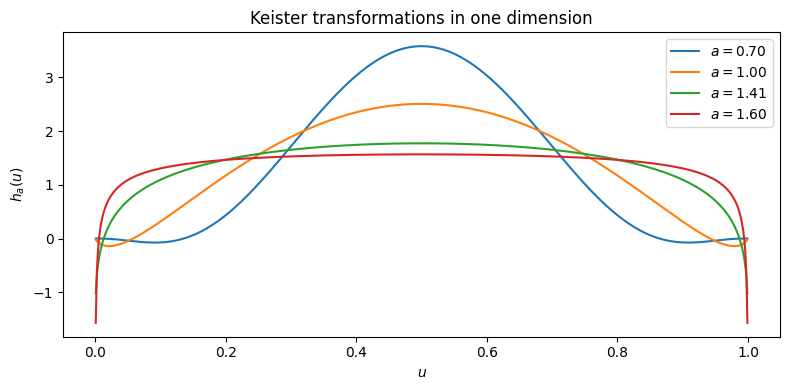

In [3]:
a_values = [0.7, 1.0, np.sqrt(2), 1.6]
u_grid = np.linspace(0.001, 0.999, 600)[:,None]
fig, ax = plt.subplots(figsize=(8,4))
for a in a_values:
    ax.plot(u_grid[:,0], keister_u(u_grid,a), label=rf"$a={a:.2f}$")
ax.set(xlabel="$u$", ylabel=r"$h_a(u)$", title="Keister transformations in one dimension")
ax.legend(); fig.tight_layout()

## Compare accuracy and work

- **Independent runs:** each row uses independent replications. Sobol' and lattice points are dependent within a run; the mean is unbiased because each point is uniform.
- **Accuracy:** empirical RMSE is measured against the independent radial-integration reference.
- **Cost:** time sampler construction, points, Gaussian transforms, and integrand evaluation for each estimate. Exclude the reference, diagnostics, and plots.
- **Comparison:** report seconds and RMSE squared × seconds. Smaller products suggest more accuracy per unit work when averaging independent fixed-size runs; they do not establish a rate as the point count changes. Repeat timings on your machine.


In [4]:
d, n, repetitions = 20, 2**14, 24
truth = keister_exact(d)
rows = []
for method in ["IID", "randomized Sobol", "randomized lattice"]:
    for a in a_values:
        estimates, seconds = [], []
        for rep in range(repetitions):
            started = time.perf_counter()
            seed = 2026 + rep
            if method == "IID":
                u = qp.IIDStdUniform(d, seed=seed)(n)
            elif method == "randomized Sobol":
                u = qp.DigitalNetB2(d, seed=seed)(n)
            else:
                u = qp.Lattice(d, seed=seed)(n)
            estimates.append(keister_u(u, a).mean())  # a is bound in this loop, not a late-bound lambda
            seconds.append(time.perf_counter()-started)
        estimates = np.asarray(estimates)
        rows.append((method,a,estimates.mean(),np.sqrt(np.mean((estimates-truth)**2)), np.mean(seconds)))
print(f"Radial-integration reference: {truth:.8f}")
from IPython.display import display, Markdown
lines = ["| Method | $a$ | Mean | Empirical RMSE | Seconds / estimate | RMSE squared × seconds |",
         "|:--|--:|--:|--:|--:|--:|"]
for method, a, mean, rmse, elapsed in rows:
    lines.append(f"| {method} | {a:.2f} | {mean:.6f} | {rmse:.6g} | {elapsed:.4f} | {rmse**2*elapsed:.5g} |")
display(Markdown("\n".join(lines)))
assert np.all(np.isfinite(np.asarray([row[2:] for row in rows])))


Radial-integration reference: -82757.01080626


| Method | $a$ | Mean | Empirical RMSE | Seconds / estimate | RMSE squared × seconds |
|:--|--:|--:|--:|--:|--:|
| IID | 0.70 | -88214.998796 | 36009.9 | 0.0059 | 7.6987e+06 |
| IID | 1.00 | -83100.599906 | 2241.31 | 0.0059 | 29445 |
| IID | 1.41 | -82741.729066 | 102.777 | 0.0059 | 61.834 |
| IID | 1.60 | -82757.614857 | 756.164 | 0.0060 | 3438.4 |
| randomized Sobol | 0.70 | -73216.999158 | 26562.7 | 0.0057 | 4.005e+06 |
| randomized Sobol | 1.00 | -82824.299415 | 1175.8 | 0.0060 | 8306.4 |
| randomized Sobol | 1.41 | -82761.224760 | 29.3483 | 0.0058 | 5.0383 |
| randomized Sobol | 1.60 | -82767.083115 | 108.285 | 0.0057 | 67.232 |
| randomized lattice | 0.70 | -74616.624325 | 25424.8 | 0.0056 | 3.6201e+06 |
| randomized lattice | 1.00 | -82789.340811 | 1110.8 | 0.0057 | 7018.7 |
| randomized lattice | 1.41 | -82760.941871 | 17.3058 | 0.0056 | 1.6871 |
| randomized lattice | 1.60 | -82753.335331 | 95.1352 | 0.0057 | 51.575 |

The best $a$ can depend on the sampling method and dimension. The $a=1.6$ case has an unbounded cube integrand but finite variance; finite variance alone does not guarantee a small empirical RMSE. Compare the observed errors across the equal-mean proposal contributions $g_a$ and their cube integrands $h_a$, rather than treat the Keister formula as one fixed estimator.


## Practical stopping criteria

- **Task:** request absolute tolerance $\varepsilon=0.005$ with a finite sample budget.
- **Integrand:** use the two-dimensional Keister expectation with $a=\sqrt2$. QMCPy's `Keister` evaluates the same $h_{\sqrt2}$ as `keister_u`.
- **Budget:** count the IID pilot or all $R=32$ QMC replications. Runtime includes integration and adaptive error assessment; it excludes the reference and plot.

### Three kinds of error assessment

- **IID CLT:** `CubMCCLT` uses an independent pilot to choose the final sample size, with a variance-inflation factor. Its interval is approximate, based on a CLT and estimated variance.
- **Replicated Sobol':** `CubQMCRepStudentT` uses $R=32$ independent scrambles. The half-width is $t_{1-\alpha/2,R-1}s_R/\sqrt R$, where $s_R$ is the sample SD of the replicate means. Dependent outputs within one scramble do not support the IID standard-error formula.
- **Walsh-coefficient decay:** `CubQMCNetG` reports a data-driven bound assuming membership in a specified cone of functions. `check_cone=True` can detect violations of necessary conditions; no detected violation does not prove membership. The corresponding lattice rule uses Fourier coefficients.

### Read the result

- **Reported radius:** for $[L,H]$, use $\max\{\widehat\mu-L,H-\widehat\mu\}$ and check it against the tolerance.
- **Qualifications:** the CLT and replication intervals are approximate; adaptive stopping adds a coverage qualification. A nominal 99% interval is not a universal 99% guarantee at the stopping time. The Walsh bound is conditional on its cone assumption, rather than a confidence interval.
- **Independent check:** the radial-integration reference measures actual error only after stopping. It never chooses the sample count.


In [5]:
import warnings
from IPython.display import display, Markdown

tolerance = 0.005
sample_budget = 2**20
stopping_dimension = 2
reference = keister_exact(stopping_dimension)
stopping_rules = [
    ("IID CLT", qp.CubMCCLT(
        qp.Keister(qp.IIDStdUniform(stopping_dimension, seed=565)),
        abs_tol=tolerance, rel_tol=0, n_init=256, n_limit=sample_budget, alpha=0.01)),
    ("Replicated Sobol", qp.CubQMCRepStudentT(
        qp.Keister(qp.DigitalNetB2(stopping_dimension, seed=565, replications=32)),
        abs_tol=tolerance, rel_tol=0, n_limit=sample_budget, alpha=0.01)),
    ("Walsh bound", qp.CubQMCNetG(
        qp.Keister(qp.DigitalNetB2(stopping_dimension, seed=565)),
        abs_tol=tolerance, rel_tol=0, n_limit=sample_budget, check_cone=True)),
    ("Sobol, tight budget", qp.CubQMCRepStudentT(
        qp.Keister(qp.DigitalNetB2(stopping_dimension, seed=565, replications=32)),
        abs_tol=1e-7, rel_tol=0, n_limit=8192, alpha=0.01)),
]
stopping_rows = []
for name, rule in stopping_rules:
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as messages:
        warnings.simplefilter("always")
        solution, data = rule.integrate()
    elapsed = time.perf_counter()-started
    estimate = float(np.asarray(solution).item())
    low = float(np.asarray(data.bound_low if name == "IID CLT" else data.comb_bound_low).item())
    high = float(np.asarray(data.bound_high if name == "IID CLT" else data.comb_bound_high).item())
    radius = max(estimate-low, high-estimate)
    cone_violation = bool(np.any(getattr(data, "cone_violation", False)))
    decision = "tolerance met" if radius <= rule.abs_tol and not cone_violation else "not met"
    stopping_rows.append((name, rule.abs_tol, estimate, low, high, radius,
                          int(data.n_total), decision, abs(estimate-reference), elapsed))
    for message in messages:
        print(f"{name}: {message.category.__name__}: {str(message.message).strip()}")

table = ["| Rule | Tolerance | Estimate | Reported interval / bound | Radius | Total samples | Decision | Actual error | Seconds |",
         "|:--|--:|--:|:--|--:|--:|:--|--:|--:|"]
for name, tol, estimate, low, high, radius, count, decision, error, elapsed in stopping_rows:
    table.append(f"| {name} | {tol:g} | {estimate:.7f} | [{low:.7f}, {high:.7f}] | {radius:.3g} | {count:,} | {decision} | {error:.3g} | {elapsed:.4f} |")
display(Markdown("\n".join(table)))
assert np.all(np.isfinite(np.asarray([row[2:6] for row in stopping_rows])))
assert all(row[7] != "tolerance met" or row[5] <= row[1] for row in stopping_rows)
assert stopping_rows[-1][7] == "not met"  # Budget exhaustion must not claim success.


Sobol, tight budget: MaxSamplesWarning: Already generated 8192 samples.
                Trying to generate 8192 new samples would exceeds n_limit = 8192.
                No more samples will be generated.
                Note that error tolerances may not be satisfied.


| Rule | Tolerance | Estimate | Reported interval / bound | Radius | Total samples | Decision | Actual error | Seconds |
|:--|--:|--:|:--|--:|--:|:--|--:|--:|
| IID CLT | 0.005 | 1.8093549 | [1.8046334, 1.8140764] | 0.00472 | 551,911 | tolerance met | 0.00117 | 0.0323 |
| Replicated Sobol | 0.005 | 1.8091262 | [1.8072861, 1.8109662] | 0.00184 | 8,192 | tolerance met | 0.00094 | 0.0007 |
| Walsh bound | 0.005 | 1.8080688 | [1.8052271, 1.8109104] | 0.00284 | 2,048 | tolerance met | 0.000118 | 0.0010 |
| Sobol, tight budget | 1e-07 | 1.8091262 | [1.8072861, 1.8109662] | 0.00184 | 8,192 | not met | 0.00094 | 0.0005 |

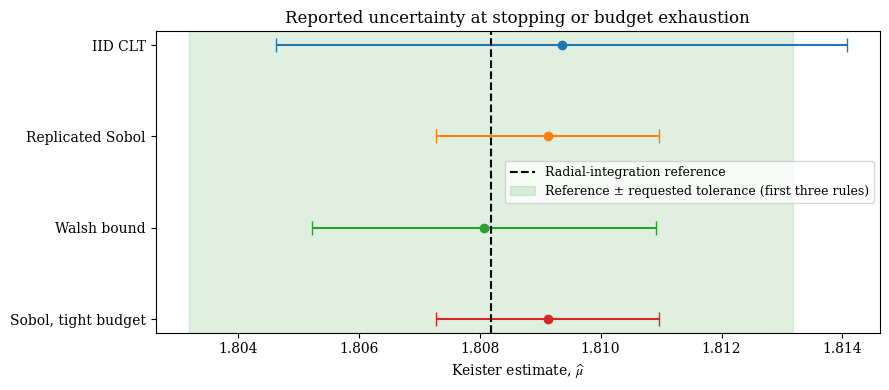

In [6]:
with plt.rc_context({"font.family": "serif", "mathtext.fontset": "stix"}):
    fig, ax = plt.subplots(figsize=(9, 4))
    for i, row in enumerate(stopping_rows):
        name, tol, estimate, low, high, radius, count, decision, error, elapsed = row
        ax.errorbar(estimate, i, xerr=[[estimate-low], [high-estimate]],
                    fmt="o", capsize=5, label=None)
    ax.axvline(reference, color="black", linestyle="--", label="Radial-integration reference")
    ax.axvspan(reference-tolerance, reference+tolerance, alpha=0.12,
               color="green", label="Reference ± requested tolerance (first three rules)")
    ax.set(yticks=np.arange(len(stopping_rows)),
           yticklabels=[row[0] for row in stopping_rows],
           xlabel=r"Keister estimate, $\widehat{\mu}$",
           title="Reported uncertainty at stopping or budget exhaustion")
    ax.invert_yaxis()
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()


- **Budget exhaustion:** the tight-budget run reports **not met**, even if its observed actual error is small. The requested tolerance was not supported by the reported interval.
- **Coverage:** an approximate interval can miss the truth while meeting its radius target. A small change between estimates or one small benchmark error does not establish reliable accuracy on a new problem.
- **Explore:** change `tolerance`, `sample_budget`, or the seeds. Compare runtime and uncertainty before checking the independent reference; keep the reference out of the stopping decision.
- **Construction details:** use [Low discrepancy constructions](../sampling/LowDiscrepancyConstructions.ipynb) for how the points are built. This notebook supplies the stopping comparison.


In [7]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 3.3 sec.
